# Creating an OME-Zarr dataset

In this notebook, we will work through creating an OME-Zarr dataset from scratch. Don't be intimidated by the number of steps here! The point is to see how the metadata is structured in OME-Zarr and how to manipulate it - we'll look at simpler ways to convert an existing dataset to OME-Zarr in a later notebook.

In [1]:
import zarr
import imageio.v3 as iio
from rich.pretty import pprint
import matplotlib.pyplot as plt
import math
import scipy.ndimage

## Zarr first 

Let's load a small example image as a numpy array. Download the `hoa_heart.zarr` dataset from the [ome zarr book repository](https://github.com/ome-zarr-models/ome-zarr-book/tree/main/book/data/hoa_heart.zarr), and put it in the `data/` directory. (The `data` directory should be inside the same folder as this notebook).

This is a downsampled version of a [heart dataset from the Human Organ Atlas](https://doi.esrf.fr/10.15151/ESRF-DC-1773966241).

In [2]:
heart_np = zarr.open_array("data/hoa_heart.zarr")[:]

In [3]:
print(heart_np.shape)

(120, 120, 139)


In [4]:
print(heart_np.dtype)

uint8


Let's display a slice through it with matplotlib:

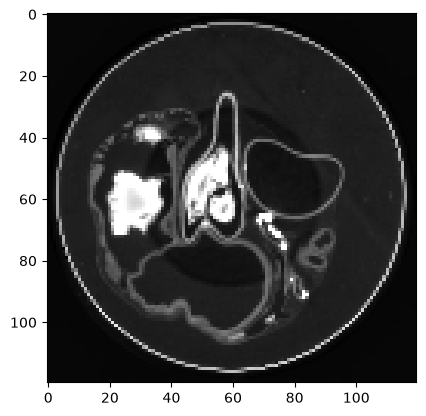

In [5]:
plt.imshow(heart_np[:, :, 60], cmap="gray")

## Converting to Zarr

We can convert this numpy array to Zarr in one step with `zarr-python`:

In [6]:
zarr.save("data/heart-test.zarr", heart_np)

But let's take a more manual approach so we can configure exactly how the Zarr array is setup:

In [7]:
# Create an empty zarr array at data/exported-heart-2.zarr with:
# - chunks of size (32 x 32 x 32)
# - overall size + data type matching our heart numpy array
# - compressed with blosc-zstd at level 3

compressors = zarr.codecs.BloscCodec(cname='zstd', clevel=3)
heart_zarr = zarr.create_array(
    store="data/exported-heart.zarr",
    shape=heart_np.shape,
    chunks=(32, 32, 32),
    dtype=heart_np.dtype,
    compressors=compressors,
    dimension_names=["x", "y", "z"]
)

This creates an empty directory with a `zarr.json` file. If you open that file, you should see the metadata given there matches the options we specified above. For example, a chunk shape of (32, 32, 32).

If we try to plot a slice through our zarr array, we see it is empty:

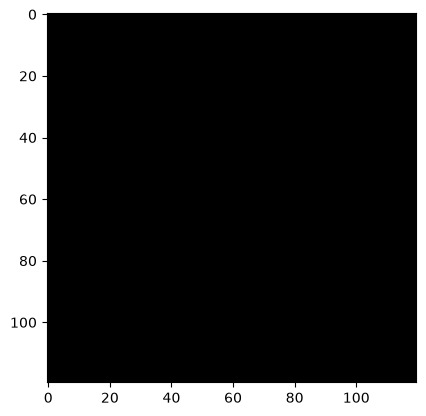

In [8]:
plt.imshow(heart_zarr[:, :, 60], cmap="gray")

Let's put our data inside:

In [9]:
# Copy the heart data into the zarr array
heart_zarr[:] = heart_np

When this is run, you should see a /c directory gets created, along with all of the chunks inside.

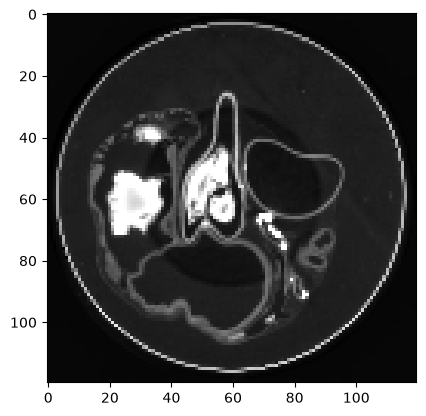

In [10]:
# Now we see our data in the zarr array
plt.imshow(heart_zarr[:, :, 60], cmap="gray")

## Convert to OME-Zarr

Let's use `ome-zarr-models` to create an OME-Zarr image instead:

In [11]:
from ome_zarr_models.v05 import Image
from ome_zarr_models.v05.axes import Axis
from pydantic_zarr.v3 import ArraySpec

voxel_size = 19.89
heart_ome_zarr = Image.new(
    array_specs = [ArraySpec.from_zarr(heart_zarr)],
    paths = ["level0"],
    axes = [
        Axis(name="x", type="space", unit="um"),
        Axis(name="y", type="space", unit="um"),
        Axis(name="z", type="space", unit="um")
    ],
    global_scale = [voxel_size, voxel_size, voxel_size],
    scales = [[1, 1, 1]],
    translations = [[0, 0, 0]],
    name = "heart_image"
)
pprint(heart_ome_zarr)

Image(
│   zarr_format=3,
│   node_type='group',
│   attributes=BaseZarrAttrs[ImageAttrs](
│   │   ome=ImageAttrs(
│   │   │   version='0.5',
│   │   │   multiscales=[
│   │   │   │   Multiscale(
│   │   │   │   │   axes=(
│   │   │   │   │   │   Axis(name='x', type='space', unit='um'),
│   │   │   │   │   │   Axis(name='y', type='space', unit='um'),
│   │   │   │   │   │   Axis(name='z', type='space', unit='um')
│   │   │   │   │   ),
│   │   │   │   │   datasets=(
│   │   │   │   │   │   Dataset(
│   │   │   │   │   │   │   path='level0',
│   │   │   │   │   │   │   coordinateTransformations=(
│   │   │   │   │   │   │   │   VectorScale(type='scale', scale=[1.0, 1.0, 1.0]),
│   │   │   │   │   │   │   │   VectorTranslation(type='translation', translation=[0.0, 0.0, 0.0])
│   │   │   │   │   │   │   )
│   │   │   │   │   │   ),
│   │   │   │   │   ),
│   │   │   │   │   coordinateTransformations=(VectorScale(type='scale', scale=[19.89, 19.89, 19.89]),),
│   │   │   │   │   metadata=None,
│   │   │   │   │   name='heart_image',
│   │   │   │   │   type=None
│   │   │   │   )
│   │   │   ]
│   │   )
│   ),
│   members={
│   │   'level0': ArraySpec(
│   │   │   zarr_format=3,
│   │   │   node_type='array',
│   │   │   attributes={},
│   │   │   shape=(120, 120, 139),
│   │   │   data_type='uint8',
│   │   │   chunk_grid={'name': 'regular', 'configuration': {'chunk_shape': (32, 32, 32)}},
│   │   │   chunk_key_encoding={'name': 'default', 'configuration': {'separator': '/'}},
│   │   │   fill_value=0,
│   │   │   codecs=(
│   │   │   │   {'name': 'bytes'},
│   │   │   │   {
│   │   │   │   │   'name': 'blosc',
│   │   │   │   │   'configuration': {
│   │   │   │   │   │   'typesize': 1,
│   │   │   │   │   │   'cname': 'zstd',
│   │   │   │   │   │   'clevel': 3,
│   │   │   │   │   │   'shuffle': 'bitshuffle',
│   │   │   │   │   │   'blocksize': 0
│   │   │   │   │   }
│   │   │   │   }
│   │   │   ),
│   │   │   storage_transformers=(),
│   │   │   dimension_names=('x', 'y', 'z')
│   │   )
│   }
)

In [12]:
ome_zarr_group = heart_ome_zarr.to_zarr("data/exported-heart.ome.zarr", path="")
print(ome_zarr_group)

<Group file://data/exported-heart.ome.zarr>


You should see a new dir at `data/exported-heart.ome.zarr`. This is a Zarr group, containing a single array 'level0'. You should see that all the OME-Zarr metadata we specified above appears in the top level `zarr.json` inside `attributes`.

In [13]:
level0_array = ome_zarr_group["level0"]
print(level0_array.shape)

(120, 120, 139)


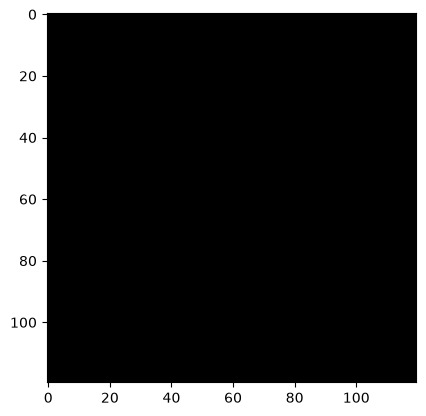

In [14]:
plt.imshow(level0_array[:, :, 60], cmap="gray")

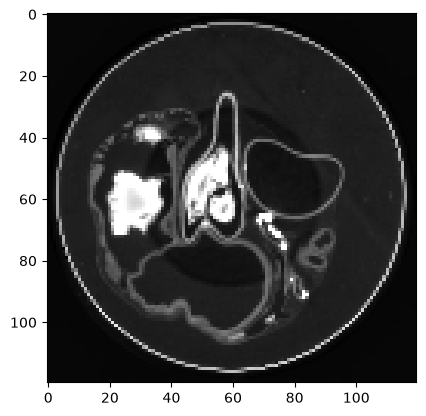

In [15]:
level0_array[:] = heart_zarr[:]
plt.imshow(level0_array[:, :, 60], cmap="gray")

So far we've made an OME-Zarr image with one dataset (the full resolution image). Usually, we want to store multiple resolution levels. How?

Here's our full-res array spec:

In [16]:
full_res_spec = ArraySpec.from_array(heart_zarr)
pprint(full_res_spec)

ArraySpec(
│   zarr_format=3,
│   node_type='array',
│   attributes={},
│   shape=(120, 120, 139),
│   data_type='uint8',
│   chunk_grid={'name': 'regular', 'configuration': {'chunk_shape': (120, 120, 139)}},
│   chunk_key_encoding={'name': 'default', 'configuration': {'separator': '/'}},
│   fill_value=0.0,
│   codecs=({'name': 'bytes'},),
│   storage_transformers=(),
│   dimension_names=('x', 'y', 'z')
)

We need to create new ones for our new levels. Let's add one more level for now that is 2x smaller:

In [17]:
downsampled_spec = full_res_spec.model_copy(
    update={"shape": tuple(math.ceil(i / 2) for i in full_res_spec.shape)
})
pprint(downsampled_spec)

ArraySpec(
│   zarr_format=3,
│   node_type='array',
│   attributes={},
│   shape=(60, 60, 70),
│   data_type='uint8',
│   chunk_grid={'name': 'regular', 'configuration': {'chunk_shape': (120, 120, 139)}},
│   chunk_key_encoding={'name': 'default', 'configuration': {'separator': '/'}},
│   fill_value=0.0,
│   codecs=({'name': 'bytes'},),
│   storage_transformers=(),
│   dimension_names=('x', 'y', 'z')
)

Now we update our OME Zarr image:

In [18]:
multiscale_image = Image.new(
    array_specs = [full_res_spec, downsampled_spec],
    paths = ["level0", "level1"],
    axes = [
        Axis(name="x", type="space", unit="um"),
        Axis(name="y", type="space", unit="um"),
        Axis(name="z", type="space", unit="um")
    ],
    global_scale = [voxel_size, voxel_size, voxel_size],
    scales = [[1, 1, 1], [2, 2, 2]],
    translations = [[0, 0, 0], [0, 0, 0]],
    name = "heart_image"
)
pprint(multiscale_image)

Image(
│   zarr_format=3,
│   node_type='group',
│   attributes=BaseZarrAttrs[ImageAttrs](
│   │   ome=ImageAttrs(
│   │   │   version='0.5',
│   │   │   multiscales=[
│   │   │   │   Multiscale(
│   │   │   │   │   axes=(
│   │   │   │   │   │   Axis(name='x', type='space', unit='um'),
│   │   │   │   │   │   Axis(name='y', type='space', unit='um'),
│   │   │   │   │   │   Axis(name='z', type='space', unit='um')
│   │   │   │   │   ),
│   │   │   │   │   datasets=(
│   │   │   │   │   │   Dataset(
│   │   │   │   │   │   │   path='level0',
│   │   │   │   │   │   │   coordinateTransformations=(
│   │   │   │   │   │   │   │   VectorScale(type='scale', scale=[1.0, 1.0, 1.0]),
│   │   │   │   │   │   │   │   VectorTranslation(type='translation', translation=[0.0, 0.0, 0.0])
│   │   │   │   │   │   │   )
│   │   │   │   │   │   ),
│   │   │   │   │   │   Dataset(
│   │   │   │   │   │   │   path='level1',
│   │   │   │   │   │   │   coordinateTransformations=(
│   │   │   │   │   │   │   │   VectorScale(type='scale', scale=[2.0, 2.0, 2.0]),
│   │   │   │   │   │   │   │   VectorTranslation(type='translation', translation=[0.0, 0.0, 0.0])
│   │   │   │   │   │   │   )
│   │   │   │   │   │   )
│   │   │   │   │   ),
│   │   │   │   │   coordinateTransformations=(VectorScale(type='scale', scale=[19.89, 19.89, 19.89]),),
│   │   │   │   │   metadata=None,
│   │   │   │   │   name='heart_image',
│   │   │   │   │   type=None
│   │   │   │   )
│   │   │   ]
│   │   )
│   ),
│   members={
│   │   'level0': ArraySpec(
│   │   │   zarr_format=3,
│   │   │   node_type='array',
│   │   │   attributes={},
│   │   │   shape=(120, 120, 139),
│   │   │   data_type='uint8',
│   │   │   chunk_grid={'name': 'regular', 'configuration': {'chunk_shape': (120, 120, 139)}},
│   │   │   chunk_key_encoding={'name': 'default', 'configuration': {'separator': '/'}},
│   │   │   fill_value=0.0,
│   │   │   codecs=({'name': 'bytes'},),
│   │   │   storage_transformers=(),
│   │   │   dimension_names=('x', 'y', 'z')
│   │   ),
│   │   'level1': ArraySpec(
│   │   │   zarr_format=3,
│   │   │   node_type='array',
│   │   │   attributes={},
│   │   │   shape=(60, 60, 70),
│   │   │   data_type='uint8',
│   │   │   chunk_grid={'name': 'regular', 'configuration': {'chunk_shape': (120, 120, 139)}},
│   │   │   chunk_key_encoding={'name': 'default', 'configuration': {'separator': '/'}},
│   │   │   fill_value=0.0,
│   │   │   codecs=({'name': 'bytes'},),
│   │   │   storage_transformers=(),
│   │   │   dimension_names=('x', 'y', 'z')
│   │   )
│   }
)

In [19]:
multiscale_group = multiscale_image.to_zarr("data/exported-heart-multiscale.ome.zarr", path="")
print(multiscale_group)

<Group file://data/exported-heart-multiscale.ome.zarr>


You should see that directory get created. It is a zarr group containing two arrays: level0 and level1. Level0 is our full resolution dataset, and level1 is our 2x downsampled one.

They're empty - fill

In [20]:
multiscale_group['level0'][:] = heart_zarr[:]
print("full scale image is", heart_zarr.shape)

downsampled_data = scipy.ndimage.zoom(heart_zarr[:], zoom=[0.5, 0.5, 0.5])
print("2x downsampled image is", downsampled_data.shape)
    
multiscale_group['level1'][:] = downsampled_data

full scale image is (120, 120, 139)
2x downsampled image is (60, 60, 70)


To check it worked, let's plot the lowest resolution level:

<Array file://data/exported-heart-multiscale.ome.zarr/level1 shape=(60, 60, 70) dtype=uint8>


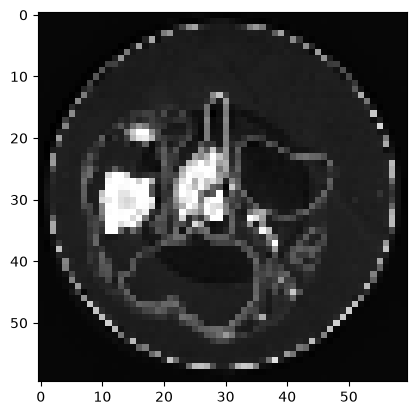

In [21]:
level1_array = multiscale_group["level1"]
print(level1_array)

plt.imshow(level1_array[:, :, 30], cmap="gray")

## Exercise

Try expanding the code above to create an OME-Zarr image with four resolution levels:
- the full-reslution dataset
- one  that is 2x smaller than the original
- one that is 4x smaller than the original
- one that is 8x smaller than the original

## Key take-aways

In summary, we have learnt that:
- Zarr arrays can be created via `zarr-python`, with full control of settings like chunk size, compressor and compresssion level.
- Metadata is written to `zarr.json` files
- OME Zarr adds extra metadata to `attributes` in `zarr.json`
- We can use `ome-zarr-models` to specify OME-Zarr metadata like axes, multiscale dataset sizes...
- Here we have built our OME-Zarr dataset step-by-step, but there are many packages available that can simplify this process